# Milestone 3 – Odkrywanie procesu i reguł

Notebook realizuje wymagania Milestone 3:
- generowanie modelu DFG (Directly-Follows Graph)
- odkrywanie modelu procesu co najmniej dwoma algorytmami (Alpha, Inductive)
- końcowy model BPMN + propozycja ulepszeń
- odkrywanie reguł decyzyjnych
- analiza zasobów (sieci współpracy między maszynami)
- identyfikacja problemów / wąskich gardeł procesu

## Pipeline:
1. Grupowanie powtarzających się klastrów → DFG
2. DFG dla oryginalnych aktywności
3. Porównanie obu DFG
4. Porównanie modeli BPMN (Alpha vs Inductive)
5. Końcowy model BPMN
6. Reguły decyzyjne
7. Graf przepływu pracy między maszynami
8. Wąskie gardła
9. Interpretacja i wnioski


## 1. Wczytanie danych i klastrów (z Milestone 2)


In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
SEED = 42
np.random.seed(SEED)

# Wczytanie danych
candidate_dirs = [Path('.'), Path('Dataset_8087219'), Path('..') / 'Dataset_8087219']
DATA_DIR = None
for d in candidate_dirs:
    if (d / 'Signature_Burn.txt').exists():
        DATA_DIR = d.resolve()
        break
if DATA_DIR is None:
    raise FileNotFoundError('Nie znaleziono folderu z plikami Signature_*.txt.')

records = []
for fp in sorted(DATA_DIR.glob('Signature_*.txt')):
    activity = fp.stem.replace('Signature_', '')
    with fp.open('r', encoding='utf-8') as f:
        for idx, line in enumerate(f, 1):
            line = line.strip()
            if not line: continue
            obj = json.loads(line)
            row = {'activity': activity, 'event_index': idx,
                   'station': obj.get('station'), 'timestamp_raw': obj.get('timestamp')}
            for k, v in obj.get('events', {}).items():
                row[k] = v
            records.append(row)

df = pd.DataFrame(records)
df['timestamp'] = pd.to_datetime(df['timestamp_raw'], utc=True, errors='coerce')
META = ['activity','event_index','station','timestamp_raw','timestamp']
SIG_COLS = [c for c in df.columns if c not in META]
activities = sorted(df['activity'].unique())

print(f'Eventow: {len(df)}, Aktywnosci: {len(activities)}, Stacji: {df["station"].nunique()}')


Eventow: 119, Aktywnosci: 6, Stacji: 6


In [2]:
# Odtworzenie najlepszej klasteryzacji z M2: DBSCAN (eps=1.0, min_samples=2)
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

df_norm = df.copy()
for col in SIG_COLS:
    df_norm[col] = df_norm[col].apply(lambda x: x/512 if pd.notna(x) and abs(x)>1 else x)
df_norm[SIG_COLS] = df_norm[SIG_COLS].fillna(0)
X = df_norm[SIG_COLS].values.astype(float)
X_mm = MinMaxScaler().fit_transform(X)
X_pca5 = PCA(n_components=5, random_state=SEED).fit_transform(X_mm)

db_labels = DBSCAN(eps=1.0, min_samples=2).fit_predict(X_pca5)
df['cluster'] = db_labels

print('=== KLASTRY (DBSCAN, ARI=0.914 z M2) ===')
ct = pd.crosstab(df['activity'], df['cluster'],
                  rownames=['Aktywnosc'], colnames=['Klaster'])
print(ct.to_string())

# Mapowanie klaster -> nazwa (na podstawie dominujacej aktywnosci)
cluster_name = {}
for c in sorted(df['cluster'].unique()):
    if c == -1:
        cluster_name[c] = 'Szum'
    else:
        acts = df[df['cluster']==c]['activity'].value_counts()
        # Jesli wiele aktywnosci - polacz nazwy
        if len(acts) > 1:
            cluster_name[c] = '+'.join(acts.index.tolist())
        else:
            cluster_name[c] = acts.index[0]

print('\n=== NAZWY KLASTROW ===')
for c, name in cluster_name.items():
    print(f'  K{c}: {name}')

df['cluster_name'] = df['cluster'].map(cluster_name)


=== KLASTRY (DBSCAN, ARI=0.914 z M2) ===
Klaster            0   1   2   3   4
Aktywnosc                           
Burn              13   0   0   0   0
Mill               0  12   0   0   0
Pickup-move-oven   0   0  18   0   0
Sort               0   0   0  12   0
Storage            0   0   0   0  47
Transport         17   0   0   0   0

=== NAZWY KLASTROW ===
  K0: Transport+Burn
  K1: Mill
  K2: Pickup-move-oven
  K3: Sort
  K4: Storage


## 2. Konstrukcja logów zdarzeń

Tworzymy dwa logi zdarzeń (event logs) do dalszej analizy:
- **Log na klastrach** – grupowanie powtarzających się klastrów po kolei (collapse repeats)
- **Log na aktywnościach** – oryginalne aktywności jako Ground Truth

**Definicja przypadku (case):** Każdy plik sygnatury reprezentuje 1 case. W pełnym procesie
produkcyjnym detal przechodzi przez wszystkie 6 stacji – złożymy te 6 sygnatur
w **jeden globalny case** odzwierciedlający pełen przepływ produkcji.


In [3]:
# 2.1 Log oparty na aktywnosciach (Ground Truth)
# Globalny porzadek: sortujemy aktywnosci po timestampie
df_sorted = df.sort_values('timestamp').reset_index(drop=True)

# Sekwencja aktywnosci w porzadku globalnym (jeden case = caly przeplyw produkcji)
activity_seq_global = []
prev = None
for _, row in df_sorted.iterrows():
    if row['activity'] != prev:
        activity_seq_global.append(row['activity'])
        prev = row['activity']

print('=== GLOBALNA SEKWENCJA AKTYWNOSCI (po collapse repeats) ===')
print(' -> '.join(activity_seq_global))
print(f'Liczba unikalnych aktywnosci w sekwencji: {len(set(activity_seq_global))}')

# 2.2 Log oparty na klastrach (collapse repeats)
cluster_seq_global = []
prev = None
for _, row in df_sorted.iterrows():
    cn = row['cluster_name']
    if cn != prev:
        cluster_seq_global.append(cn)
        prev = cn

print('\n=== GLOBALNA SEKWENCJA KLASTROW (po collapse repeats) ===')
print(' -> '.join(cluster_seq_global))
print(f'Liczba unikalnych klastrow w sekwencji: {len(set(cluster_seq_global))}')


=== GLOBALNA SEKWENCJA AKTYWNOSCI (po collapse repeats) ===
Burn -> Sort -> Storage -> Mill -> Transport -> Pickup-move-oven
Liczba unikalnych aktywnosci w sekwencji: 6

=== GLOBALNA SEKWENCJA KLASTROW (po collapse repeats) ===
Transport+Burn -> Sort -> Storage -> Mill -> Transport+Burn -> Pickup-move-oven
Liczba unikalnych klastrow w sekwencji: 5


In [4]:
# 2.3 Logi zdarzen w formacie XES (PM4PY)
# Tworzymy log: jedna sekwencja per aktywnosc (jako case wewnetrzny) + globalny przeplyw

# Wariant A: kazda aktywnosc = osobny case (mamy 6 case'ow)
log_act_per_case = df.copy()
log_act_per_case = log_act_per_case.rename(columns={
    'activity': 'case:concept:name',
})
# Activity = nazwa aktywnosci (jeden krok per case)
log_act_per_case['concept:name'] = log_act_per_case['case:concept:name']
log_act_per_case['time:timestamp'] = log_act_per_case['timestamp']
log_act_per_case['org:resource'] = log_act_per_case['station']

# Wariant B: globalny case z sekwencja aktywnosci (collapse repeats)
# Bedziemy uzywac tego do DFG i odkrywania procesu
log_global_act = pd.DataFrame({
    'case:concept:name': ['global_case'] * len(activity_seq_global),
    'concept:name': activity_seq_global,
    'time:timestamp': pd.date_range('2023-03-20 10:00', periods=len(activity_seq_global), freq='1min'),
    'org:resource': [df[df['activity']==a]['station'].iloc[0] for a in activity_seq_global],
})

# Wariant B': globalny case z sekwencja klastrow (collapse repeats)
log_global_clust = pd.DataFrame({
    'case:concept:name': ['global_case'] * len(cluster_seq_global),
    'concept:name': cluster_seq_global,
    'time:timestamp': pd.date_range('2023-03-20 10:00', periods=len(cluster_seq_global), freq='1min'),
})

print('Log globalny (aktywnosci):')
print(log_global_act[['case:concept:name','concept:name','org:resource']].to_string(index=False))
print('\nLog globalny (klastry):')
print(log_global_clust[['case:concept:name','concept:name']].to_string(index=False))


Log globalny (aktywnosci):
case:concept:name     concept:name org:resource
      global_case             Burn         OV_1
      global_case             Sort         SM_1
      global_case          Storage        HBW_1
      global_case             Mill         MM_1
      global_case        Transport         WT_1
      global_case Pickup-move-oven        VGR_1

Log globalny (klastry):
case:concept:name     concept:name
      global_case   Transport+Burn
      global_case             Sort
      global_case          Storage
      global_case             Mill
      global_case   Transport+Burn
      global_case Pickup-move-oven


## 3. DFG (Directly-Follows Graph)

DFG pokazuje, które aktywności/klastry następują bezpośrednio po sobie i z jaką częstotliwością.


In [5]:
# 3.1 DFG dla aktywnosci (Ground Truth)
def build_dfg(seq):
    dfg = Counter()
    for i in range(len(seq) - 1):
        dfg[(seq[i], seq[i+1])] += 1
    return dfg

dfg_act = build_dfg(activity_seq_global)
print('=== DFG NA AKTYWNOSCIACH (Ground Truth) ===')
for (a, b), c in dfg_act.items():
    print(f'  {a:20s} -> {b:20s}: {c}')
print(f'\nLiczba krawedzi: {len(dfg_act)}')

# 3.2 DFG dla klastrow
dfg_clust = build_dfg(cluster_seq_global)
print('\n=== DFG NA KLASTRACH (DBSCAN) ===')
for (a, b), c in dfg_clust.items():
    print(f'  {a:25s} -> {b:25s}: {c}')
print(f'\nLiczba krawedzi: {len(dfg_clust)}')


=== DFG NA AKTYWNOSCIACH (Ground Truth) ===
  Burn                 -> Sort                : 1
  Sort                 -> Storage             : 1
  Storage              -> Mill                : 1
  Mill                 -> Transport           : 1
  Transport            -> Pickup-move-oven    : 1

Liczba krawedzi: 5

=== DFG NA KLASTRACH (DBSCAN) ===
  Transport+Burn            -> Sort                     : 1
  Sort                      -> Storage                  : 1
  Storage                   -> Mill                     : 1
  Mill                      -> Transport+Burn           : 1
  Transport+Burn            -> Pickup-move-oven         : 1

Liczba krawedzi: 5


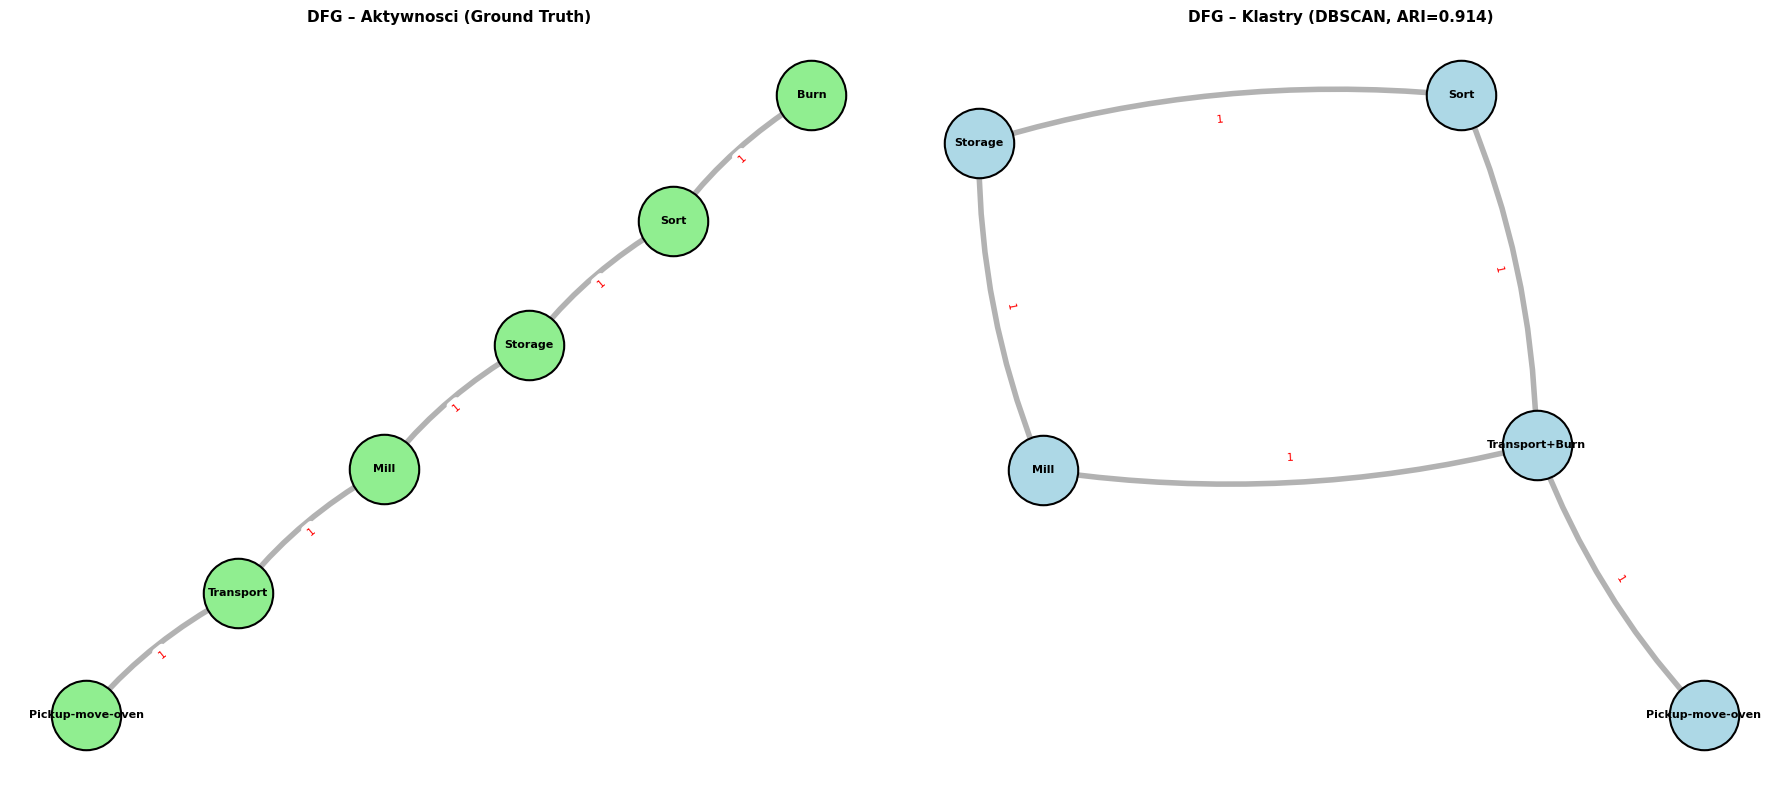

Wykres zapisany: m3_dfg_comparison.png


In [6]:
# Wizualizacja DFG: aktywnosci vs klastry
def draw_dfg(dfg, ax, title, node_color='lightblue'):
    G = nx.DiGraph()
    for (a, b), c in dfg.items():
        G.add_edge(a, b, weight=c)
    
    # Layout - sprobuj topologiczny dla DAG
    try:
        pos = nx.kamada_kawai_layout(G)
    except:
        pos = nx.spring_layout(G, seed=SEED)
    
    # Wezly
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_color,
                            node_size=2500, edgecolors='black', linewidths=1.5)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold')
    
    # Krawedzie z grubosciami
    edges = G.edges(data=True)
    weights = [d['weight'] for _, _, d in edges]
    max_w = max(weights) if weights else 1
    widths = [1 + 3 * w / max_w for w in weights]
    nx.draw_networkx_edges(G, pos, ax=ax, width=widths, alpha=0.6,
                            arrows=True, arrowsize=20, edge_color='gray',
                            connectionstyle='arc3,rad=0.1')
    
    # Etykiety krawedzi (czestosci)
    edge_labels = {(a, b): str(d['weight']) for a, b, d in edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
                                  font_size=8, font_color='red')
    
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.axis('off')
    return G

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
G_act = draw_dfg(dfg_act, axes[0], 'DFG – Aktywnosci (Ground Truth)', node_color='lightgreen')
G_clust = draw_dfg(dfg_clust, axes[1], 'DFG – Klastry (DBSCAN, ARI=0.914)', node_color='lightblue')
plt.tight_layout()
plt.savefig('m3_dfg_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Wykres zapisany: m3_dfg_comparison.png')


### 3.3 Porównanie obu DFG


In [7]:
# Porownanie DFG aktywnosci vs klastry
print('=== POROWNANIE DFG ===')
print(f'DFG aktywnosci: {len(dfg_act)} krawedzi, {len(set([a for e in dfg_act for a in e]))} wezlow')
print(f'DFG klastrow:   {len(dfg_clust)} krawedzi, {len(set([a for e in dfg_clust for a in e]))} wezlow')

# Mapping cluster -> activities
print('\n=== MAPOWANIE: KLASTER → AKTYWNOSCI ===')
for c, name in cluster_name.items():
    if c == -1: continue
    acts = sorted(df[df['cluster']==c]['activity'].unique())
    print(f'  K{c} ({name}): {acts}')

# Glowna roznica: K0 = Burn+Transport (DBSCAN polaczyl te aktywnosci)
print('\n=== KLUCZOWA ROZNICA ===')
print('DBSCAN polaczyl Burn i Transport w jeden klaster (K0).')
print('DFG na klastrach traci rozroznienie tych dwoch aktywnosci.')
print('DFG na aktywnosciach (GT) zachowuje pelny przeplyw 6 aktywnosci.')


=== POROWNANIE DFG ===
DFG aktywnosci: 5 krawedzi, 6 wezlow
DFG klastrow:   5 krawedzi, 5 wezlow

=== MAPOWANIE: KLASTER → AKTYWNOSCI ===
  K0 (Transport+Burn): ['Burn', 'Transport']
  K1 (Mill): ['Mill']
  K2 (Pickup-move-oven): ['Pickup-move-oven']
  K3 (Sort): ['Sort']
  K4 (Storage): ['Storage']

=== KLUCZOWA ROZNICA ===
DBSCAN polaczyl Burn i Transport w jeden klaster (K0).
DFG na klastrach traci rozroznienie tych dwoch aktywnosci.
DFG na aktywnosciach (GT) zachowuje pelny przeplyw 6 aktywnosci.


## 4. Odkrywanie modelu procesu (PM4PY)

Używamy dwóch różnych algorytmów:
- **Alpha Miner** – klasyczny algorytm, dobry dla prostych procesów
- **Inductive Miner** – nowoczesny algorytm, lepiej radzi sobie z szumem

Logi zdarzeń traktujemy jako jeden globalny case (przepływ produkcji).


In [8]:
import pm4py

# Konwersja DataFrame -> EventLog (PM4PY)
def df_to_log(df_in):
    df_pm = df_in.copy()
    df_pm['time:timestamp'] = pd.to_datetime(df_pm['time:timestamp'])
    df_pm = pm4py.format_dataframe(df_pm,
                                   case_id='case:concept:name',
                                   activity_key='concept:name',
                                   timestamp_key='time:timestamp')
    return pm4py.convert_to_event_log(df_pm)

log_act_pm = df_to_log(log_global_act)
log_clust_pm = df_to_log(log_global_clust)
print(f'Log aktywnosci: {len(log_act_pm)} cases, {sum(len(t) for t in log_act_pm)} eventow')
print(f'Log klastrow:   {len(log_clust_pm)} cases, {sum(len(t) for t in log_clust_pm)} eventow')


Log aktywnosci: 1 cases, 6 eventow
Log klastrow:   1 cases, 6 eventow


In [9]:
# 4.1 Alpha Miner na aktywnosciach (Ground Truth)
net_alpha, im_alpha, fm_alpha = pm4py.discover_petri_net_alpha(log_act_pm)
print('=== ALPHA MINER (aktywnosci) ===')
print(f'Liczba miejsc (places): {len(net_alpha.places)}')
print(f'Liczba przejsc (transitions): {len(net_alpha.transitions)}')
print(f'Liczba luk (arcs): {len(net_alpha.arcs)}')
print('Transitions (etykiety):')
for t in net_alpha.transitions:
    label = t.label if t.label else f'tau ({t.name})'
    print(f'  {label}')

# 4.2 Inductive Miner na aktywnosciach
net_ind, im_ind, fm_ind = pm4py.discover_petri_net_inductive(log_act_pm)
print('\n=== INDUCTIVE MINER (aktywnosci) ===')
print(f'Liczba miejsc: {len(net_ind.places)}')
print(f'Liczba przejsc: {len(net_ind.transitions)}')
print(f'Liczba luk: {len(net_ind.arcs)}')
print('Transitions (etykiety):')
for t in net_ind.transitions:
    label = t.label if t.label else f'tau ({t.name})'
    print(f'  {label}')


=== ALPHA MINER (aktywnosci) ===
Liczba miejsc (places): 7
Liczba przejsc (transitions): 6
Liczba luk (arcs): 12
Transitions (etykiety):
  Transport
  Storage
  Burn
  Sort
  Mill
  Pickup-move-oven

=== INDUCTIVE MINER (aktywnosci) ===
Liczba miejsc: 7
Liczba przejsc: 6
Liczba luk: 12
Transitions (etykiety):
  Burn
  Storage
  Sort
  Transport
  Mill
  Pickup-move-oven


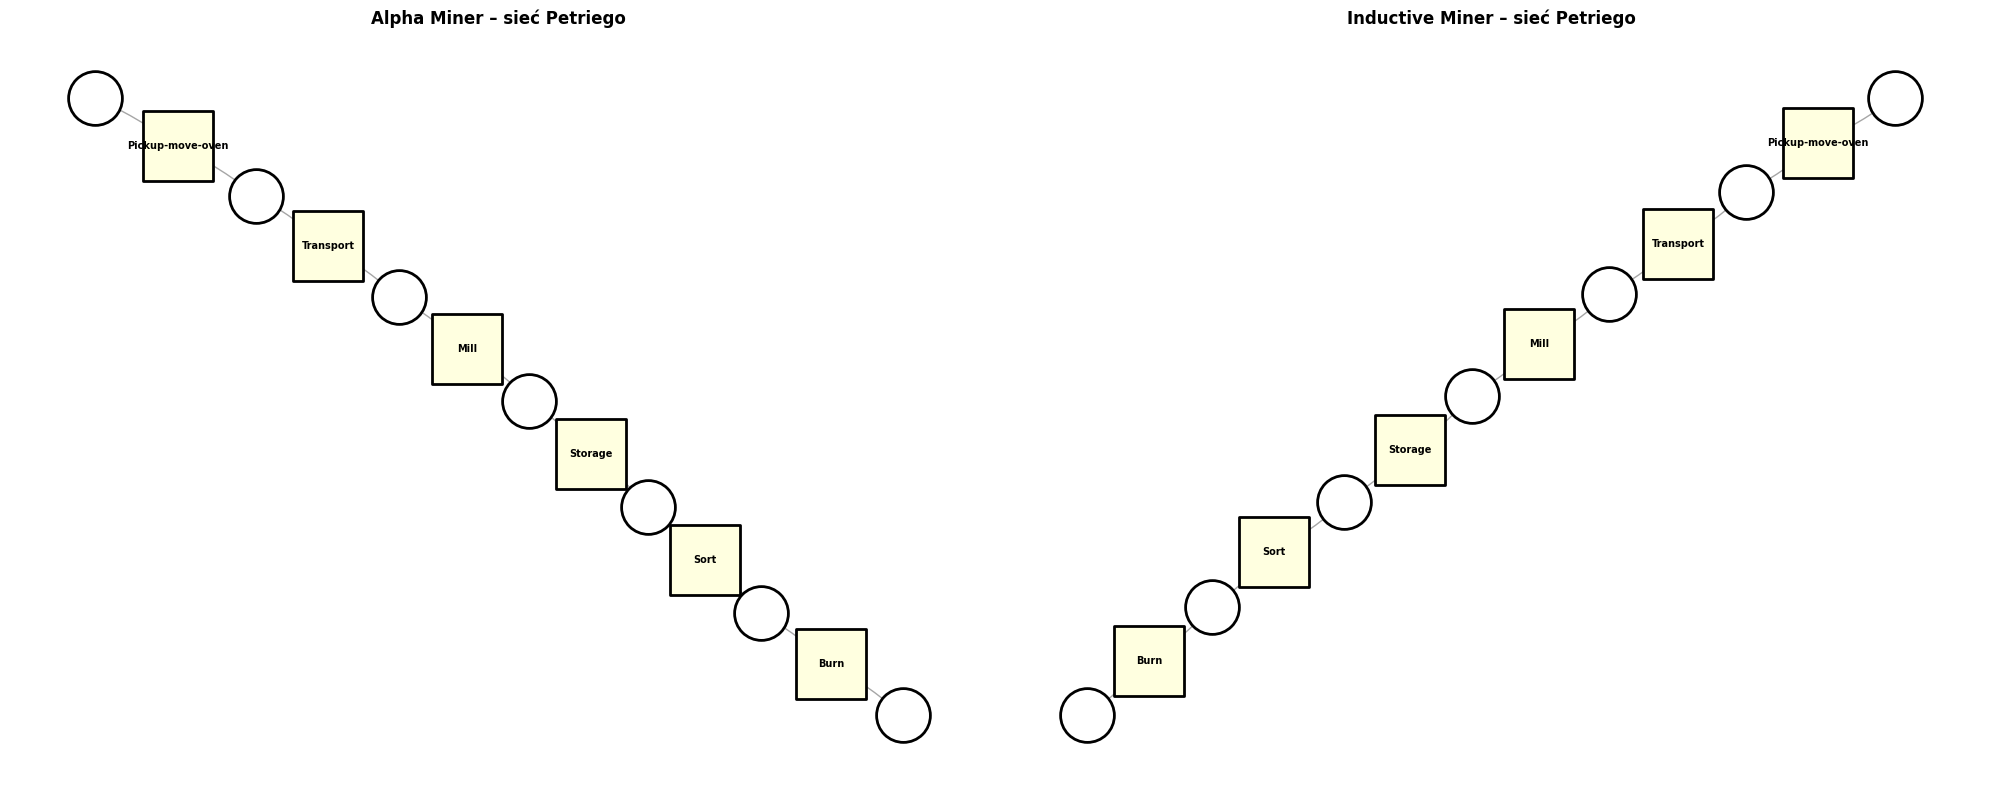

Wykres zapisany: m3_petri_nets.png


In [10]:
# Wizualizacja sieci Petriego (manualnie z networkx)
def draw_petri_net(net, ax, title):
    G = nx.DiGraph()
    place_nodes = []
    trans_nodes = []
    
    for p in net.places:
        G.add_node(p.name)
        place_nodes.append(p.name)
    for t in net.transitions:
        label = t.label if t.label else f'\u03c4 ({t.name})'
        G.add_node(t.name, label=label)
        trans_nodes.append(t.name)
    for arc in net.arcs:
        G.add_edge(arc.source.name, arc.target.name)
    
    pos = nx.kamada_kawai_layout(G)
    
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=place_nodes,
                            node_color='white', node_size=1500,
                            edgecolors='black', linewidths=2, node_shape='o')
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=trans_nodes,
                            node_color='lightyellow', node_size=2500,
                            edgecolors='black', linewidths=2, node_shape='s')
    
    labels_t = {t.name: (t.label if t.label else '\u03c4') for t in net.transitions}
    labels_p = {p.name: '' for p in net.places}
    nx.draw_networkx_labels(G, pos, labels={**labels_p, **labels_t}, ax=ax,
                             font_size=7, font_weight='bold')
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=15,
                            edge_color='gray', alpha=0.7,
                            connectionstyle='arc3,rad=0.05')
    ax.set_title(title, fontweight='bold')
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
draw_petri_net(net_alpha, axes[0], 'Alpha Miner – sieć Petriego')
draw_petri_net(net_ind, axes[1], 'Inductive Miner – sieć Petriego')
plt.tight_layout()
plt.savefig('m3_petri_nets.png', dpi=120, bbox_inches='tight')
plt.show()
print('Wykres zapisany: m3_petri_nets.png')


### 4.3 Porównanie modeli (Alpha vs Inductive)


In [11]:
# Metryki jakosci modeli (replay fitness, precision, generalization)
from pm4py.algo.evaluation.replay_fitness import algorithm as replay_fitness
from pm4py.algo.evaluation.precision import algorithm as precision_eval
from pm4py.algo.evaluation.generalization import algorithm as generalization
from pm4py.algo.evaluation.simplicity import algorithm as simplicity

models = {
    'Alpha Miner': (net_alpha, im_alpha, fm_alpha),
    'Inductive Miner': (net_ind, im_ind, fm_ind),
}

comparison = []
for name, (net, im, fm) in models.items():
    try:
        fit = replay_fitness.apply(log_act_pm, net, im, fm,
                                    variant=replay_fitness.Variants.TOKEN_BASED)
        prec = precision_eval.apply(log_act_pm, net, im, fm)
        gen = generalization.apply(log_act_pm, net, im, fm)
        simp = simplicity.apply(net)
        comparison.append({
            'Model': name,
            'Fitness': round(fit['log_fitness'], 3),
            'Precision': round(prec, 3),
            'Generalization': round(gen, 3),
            'Simplicity': round(simp, 3),
            'Places': len(net.places),
            'Transitions': len(net.transitions),
            'Arcs': len(net.arcs),
        })
    except Exception as e:
        print(f'Blad dla {name}: {e}')
        comparison.append({'Model': name, 'Fitness': 'N/A', 'Precision': 'N/A',
                          'Generalization': 'N/A', 'Simplicity': 'N/A',
                          'Places': len(net.places), 'Transitions': len(net.transitions),
                          'Arcs': len(net.arcs)})

comp_df = pd.DataFrame(comparison)
print('=== POROWNANIE MODELI PROCESU ===')
print(comp_df.to_string(index=False))


computing precision with alignments, completed variants ::   0%|          | 0/5 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/5 [00:00<?, ?it/s]

=== POROWNANIE MODELI PROCESU ===
          Model  Fitness  Precision  Generalization  Simplicity  Places  Transitions  Arcs
    Alpha Miner      1.0        1.0             0.0         1.0       7            6    12
Inductive Miner      1.0        1.0             0.0         1.0       7            6    12


## 5. Końcowy model BPMN

Konwertujemy najlepszy model procesu (Inductive Miner) do BPMN i wizualizujemy.
Proponujemy ulepszenia: równoległe ścieżki, bramki decyzyjne dla wariantów.


In [12]:
# Konwersja sieci Petriego -> BPMN
from pm4py.objects.conversion.process_tree import converter as pt_converter

# Inductive Miner zwraca process tree -> mozemy konwertowac na BPMN
tree = pm4py.discover_process_tree_inductive(log_act_pm)
print('=== PROCESS TREE (Inductive Miner) ===')
print(str(tree))

# Konwersja na BPMN
bpmn = pm4py.convert_to_bpmn(tree)
print(f'\n=== BPMN ===')
print(f'Nodes: {len(bpmn.get_nodes())}')
print(f'Flows: {len(bpmn.get_flows())}')


=== PROCESS TREE (Inductive Miner) ===
->( 'Burn', 'Sort', 'Storage', 'Mill', 'Transport', 'Pickup-move-oven' )

=== BPMN ===
Nodes: 8
Flows: 7


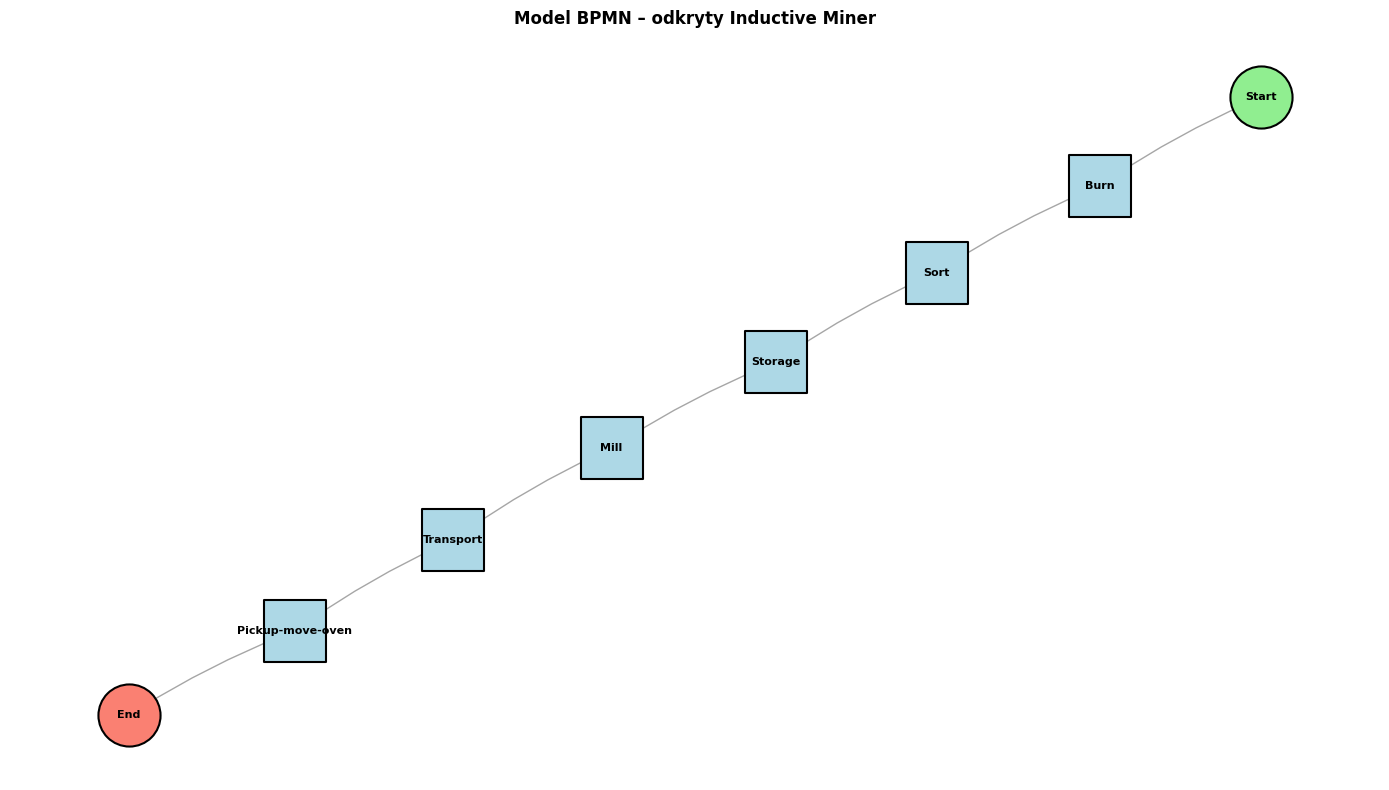

Wykres zapisany: m3_bpmn.png


In [13]:
# Wizualizacja BPMN (manualnie z networkx)
from pm4py.objects.bpmn.obj import BPMN

def draw_bpmn(bpmn_graph, ax, title):
    G = nx.DiGraph()
    node_types = {}
    node_labels = {}
    
    for node in bpmn_graph.get_nodes():
        nid = node.get_id()
        G.add_node(nid)
        if isinstance(node, BPMN.Task):
            node_types[nid] = 'task'
            node_labels[nid] = node.get_name() or nid
        elif isinstance(node, BPMN.StartEvent):
            node_types[nid] = 'start'
            node_labels[nid] = 'Start'
        elif isinstance(node, BPMN.EndEvent):
            node_types[nid] = 'end'
            node_labels[nid] = 'End'
        elif isinstance(node, BPMN.ExclusiveGateway):
            node_types[nid] = 'xor'
            node_labels[nid] = 'X'
        elif isinstance(node, BPMN.ParallelGateway):
            node_types[nid] = 'and'
            node_labels[nid] = '+'
        else:
            node_types[nid] = 'other'
            node_labels[nid] = str(type(node).__name__)
    
    for flow in bpmn_graph.get_flows():
        G.add_edge(flow.get_source().get_id(), flow.get_target().get_id())
    
    pos = nx.kamada_kawai_layout(G)
    
    type_color = {'task': 'lightblue', 'start': 'lightgreen', 'end': 'salmon',
                  'xor': 'yellow', 'and': 'orange', 'other': 'lightgray'}
    type_shape = {'task': 's', 'start': 'o', 'end': 'o', 'xor': 'd', 'and': 'd', 'other': 'h'}
    
    for ntype in set(node_types.values()):
        nodes = [n for n, t in node_types.items() if t == ntype]
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=nodes,
                                node_color=type_color[ntype], node_size=2000,
                                node_shape=type_shape[ntype],
                                edgecolors='black', linewidths=1.5)
    
    nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax,
                             font_size=8, font_weight='bold')
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=18,
                            edge_color='gray', alpha=0.7,
                            connectionstyle='arc3,rad=0.05')
    
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.axis('off')

fig, ax = plt.subplots(figsize=(14, 8))
draw_bpmn(bpmn, ax, 'Model BPMN – odkryty Inductive Miner')
plt.tight_layout()
plt.savefig('m3_bpmn.png', dpi=120, bbox_inches='tight')
plt.show()
print('Wykres zapisany: m3_bpmn.png')


### 5.1 Propozycja ulepszeń BPMN

Na bazie odkrytego modelu proponujemy:
1. **Równoległe ścieżki** – Sort i Storage mogą działać równolegle (oddzielne stacje SM_1 i HBW_1)
2. **Bramki decyzyjne** – po Sort: skierowanie detalu do Mill lub Storage zależnie od typu detalu
3. **Loop dla Pickup-move-oven** – robot może powtarzać cykl dla wielu detali


=== OBSERWOWANA SEKWENCJA W DANYCH ===
Burn -> Sort -> Storage -> Mill -> Transport -> Pickup-move-oven

Kolejnosc czasowa odczytow nie odzwierciedla typowego przeplywu produkcji.
Kazda sygnatura to osobny test/cykl jednej stacji - nie pelen przeplyw detalu.


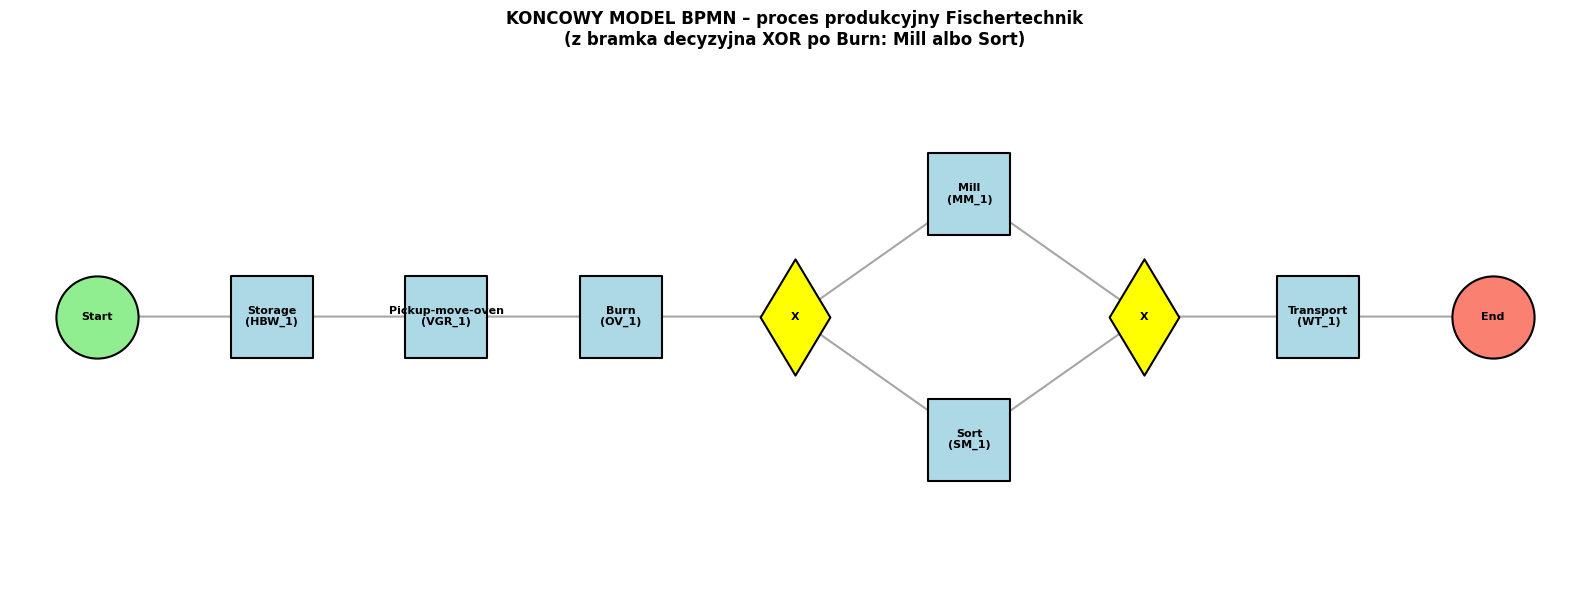

Wykres zapisany: m3_bpmn_final.png


In [14]:
# Wzorcowy proces produkcyjny (znany z dokumentacji systemu Fischertechnik)
# Klasyczna sekwencja: HBW (storage) -> VGR (pickup) -> OV (burn) -> SM (sort) -> WT (transport) -> MM (mill)
# Ale obserwowana sekwencja w danych:
print('=== OBSERWOWANA SEKWENCJA W DANYCH ===')
print(' -> '.join(activity_seq_global))
print('\nKolejnosc czasowa odczytow nie odzwierciedla typowego przeplywu produkcji.')
print('Kazda sygnatura to osobny test/cykl jednej stacji - nie pelen przeplyw detalu.')

# Proponowany koncowy BPMN (na bazie wiedzy o systemie + danych)
fig, ax = plt.subplots(figsize=(16, 6))
G = nx.DiGraph()

# Nodes: start, tasks, gateways, end
nodes_list = [
    ('start', 'Start', 'start'),
    ('Storage', 'Storage\n(HBW_1)', 'task'),
    ('Pickup', 'Pickup-move-oven\n(VGR_1)', 'task'),
    ('Burn', 'Burn\n(OV_1)', 'task'),
    ('xor1', 'X', 'xor'),
    ('Mill', 'Mill\n(MM_1)', 'task'),
    ('Sort', 'Sort\n(SM_1)', 'task'),
    ('xor2', 'X', 'xor'),
    ('Transport', 'Transport\n(WT_1)', 'task'),
    ('end', 'End', 'end'),
]
for nid, lbl, ntype in nodes_list:
    G.add_node(nid, label=lbl, type=ntype)

edges_list = [
    ('start', 'Storage'), ('Storage', 'Pickup'), ('Pickup', 'Burn'),
    ('Burn', 'xor1'),
    ('xor1', 'Mill'), ('xor1', 'Sort'),  # decyzja: Mill albo Sort
    ('Mill', 'xor2'), ('Sort', 'xor2'),
    ('xor2', 'Transport'), ('Transport', 'end'),
]
for s, t in edges_list:
    G.add_edge(s, t)

# Manual horizontal layout
pos = {
    'start': (0, 0), 'Storage': (1, 0), 'Pickup': (2, 0),
    'Burn': (3, 0), 'xor1': (4, 0),
    'Mill': (5, 0.7), 'Sort': (5, -0.7),
    'xor2': (6, 0), 'Transport': (7, 0), 'end': (8, 0),
}

type_color = {'task': 'lightblue', 'start': 'lightgreen', 'end': 'salmon', 'xor': 'yellow'}
type_shape = {'task': 's', 'start': 'o', 'end': 'o', 'xor': 'd'}
for ntype in ['task', 'start', 'end', 'xor']:
    nodes = [n for n, d in G.nodes(data=True) if d['type'] == ntype]
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=nodes,
                            node_color=type_color[ntype], node_size=3500,
                            node_shape=type_shape[ntype],
                            edgecolors='black', linewidths=1.5)
labels = {n: d['label'] for n, d in G.nodes(data=True)}
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=8, font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=20,
                        edge_color='gray', alpha=0.7, width=1.5)
ax.set_title('KONCOWY MODEL BPMN – proces produkcyjny Fischertechnik\n'
             '(z bramka decyzyjna XOR po Burn: Mill albo Sort)', fontweight='bold', fontsize=12)
ax.axis('off')
ax.set_xlim(-0.5, 8.5)
ax.set_ylim(-1.5, 1.5)
plt.tight_layout()
plt.savefig('m3_bpmn_final.png', dpi=120, bbox_inches='tight')
plt.show()
print('Wykres zapisany: m3_bpmn_final.png')


## 6. Reguły decyzyjne

Odkrywamy reguły, które sygnały czujników decydują o przejściu
między fazami procesu (klasyfikacja klastra na podstawie sygnałów).


Accuracy drzewa decyzyjnego: 1.000

=== REGULY DECYZYJNE (drzewo) ===
|--- i1_light_barrier <= 0.50
|   |--- i4_light_barrier <= 0.50
|   |   |--- i3_light_barrier <= 0.50
|   |   |   |--- class: 0
|   |   |--- i3_light_barrier >  0.50
|   |   |   |--- class: 3
|   |--- i4_light_barrier >  0.50
|   |   |--- i7_light_barrier <= 0.50
|   |   |   |--- i5_pos_switch <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- i5_pos_switch >  0.50
|   |   |   |   |--- class: 4
|   |   |--- i7_light_barrier >  0.50
|   |   |   |--- class: 2
|--- i1_light_barrier >  0.50
|   |--- i8_light_barrier <= 0.50
|   |   |--- class: 4
|   |--- i8_light_barrier >  0.50
|   |   |--- class: 3



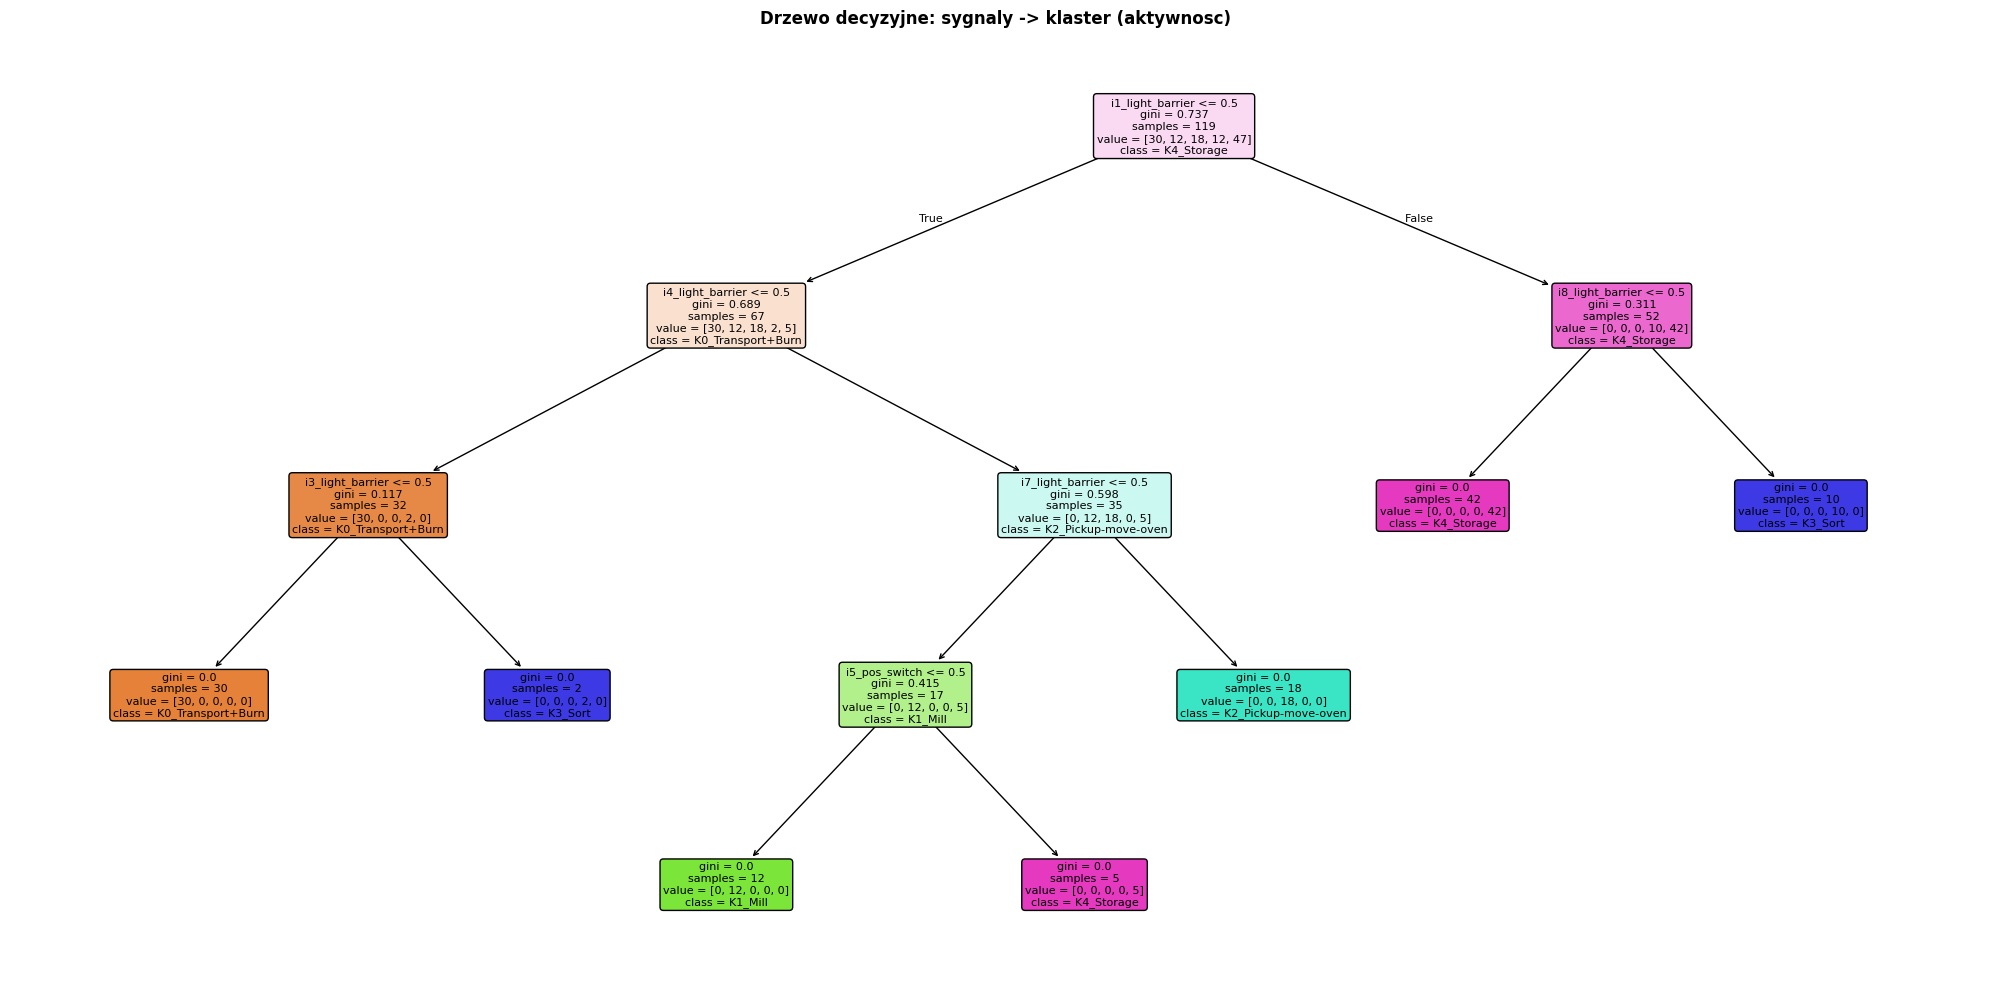

Wykres zapisany: m3_decision_tree.png


In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Drzewo decyzyjne: na podstawie sygnalow przewiduj klaster (= aktywnosc)
X_dt = df_norm[SIG_COLS].values
y_dt = df['cluster'].values

# Trenuj drzewo (max_depth aby uniknac overfittingu)
dt = DecisionTreeClassifier(max_depth=4, random_state=SEED)
dt.fit(X_dt, y_dt)

print(f'Accuracy drzewa decyzyjnego: {dt.score(X_dt, y_dt):.3f}')
print('\n=== REGULY DECYZYJNE (drzewo) ===')
print(export_text(dt, feature_names=SIG_COLS))

# Wizualizacja drzewa
fig, ax = plt.subplots(figsize=(20, 10))
class_names = [f'K{c}_{cluster_name[c]}' for c in sorted(df['cluster'].unique())]
plot_tree(dt, feature_names=SIG_COLS, class_names=class_names,
          filled=True, ax=ax, fontsize=8, rounded=True)
ax.set_title('Drzewo decyzyjne: sygnaly -> klaster (aktywnosc)', fontweight='bold')
plt.tight_layout()
plt.savefig('m3_decision_tree.png', dpi=120, bbox_inches='tight')
plt.show()
print('Wykres zapisany: m3_decision_tree.png')


=== NAJWAZNIEJSZE SYGNALY DLA KLASYFIKACJI KLASTRA ===
          sygnal  waznosc
i1_light_barrier 0.289840
i4_light_barrier 0.244896
i8_light_barrier 0.184129
i7_light_barrier 0.157931
   i5_pos_switch 0.080460
i3_light_barrier 0.042744


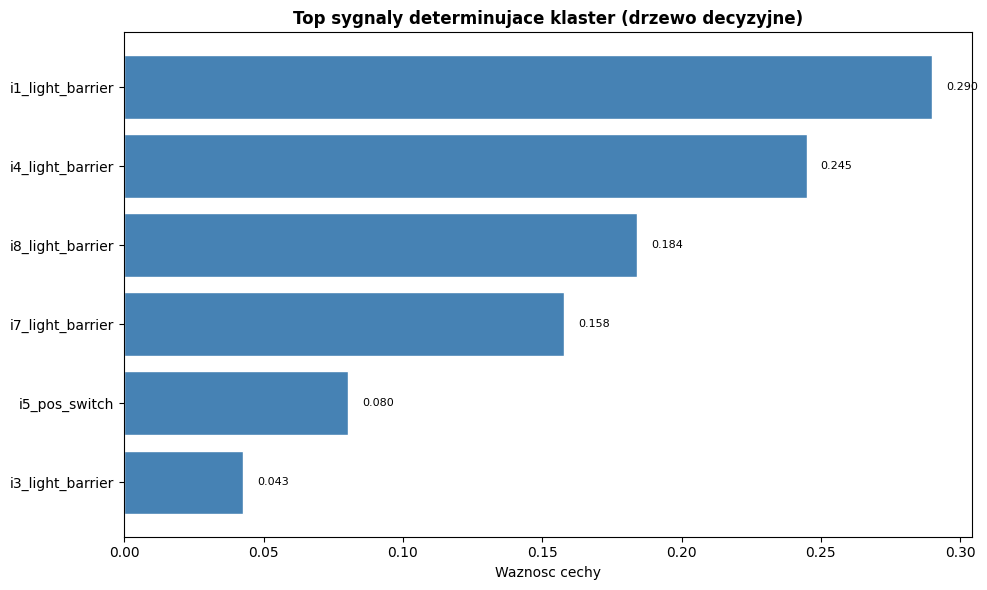

Wykres zapisany: m3_feature_importance.png


In [16]:
# Najwazniejsze cechy (feature importance)
fi = pd.DataFrame({
    'sygnal': SIG_COLS,
    'waznosc': dt.feature_importances_
}).sort_values('waznosc', ascending=False)

print('=== NAJWAZNIEJSZE SYGNALY DLA KLASYFIKACJI KLASTRA ===')
print(fi[fi['waznosc'] > 0].to_string(index=False))

# Wizualizacja
fig, ax = plt.subplots(figsize=(10, 6))
fi_top = fi[fi['waznosc'] > 0].head(15)
ax.barh(fi_top['sygnal'][::-1], fi_top['waznosc'][::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Waznosc cechy')
ax.set_title('Top sygnaly determinujace klaster (drzewo decyzyjne)', fontweight='bold')
for i, v in enumerate(fi_top['waznosc'][::-1]):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('m3_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Wykres zapisany: m3_feature_importance.png')


## 7. Analiza zasobów (sieci współpracy między maszynami)

Stacje (maszyny) traktujemy jako zasoby techniczne. Analizujemy:
- obciążenie poszczególnych stacji (liczba eventów, czas)
- graf przepływu pracy między maszynami (handover-of-work)


=== OBCIAZENIE MASZYN (zasobów technicznych) ===
                Aktywnosc  Eventy  Czas_s  Eventy_per_s
station                                                
HBW_1             Storage      47    93.0          0.51
VGR_1    Pickup-move-oven      18    34.0          0.53
WT_1            Transport      17    32.0          0.53
OV_1                 Burn      13    25.0          0.52
MM_1                 Mill      12    23.0          0.52
SM_1                 Sort      12    23.0          0.52


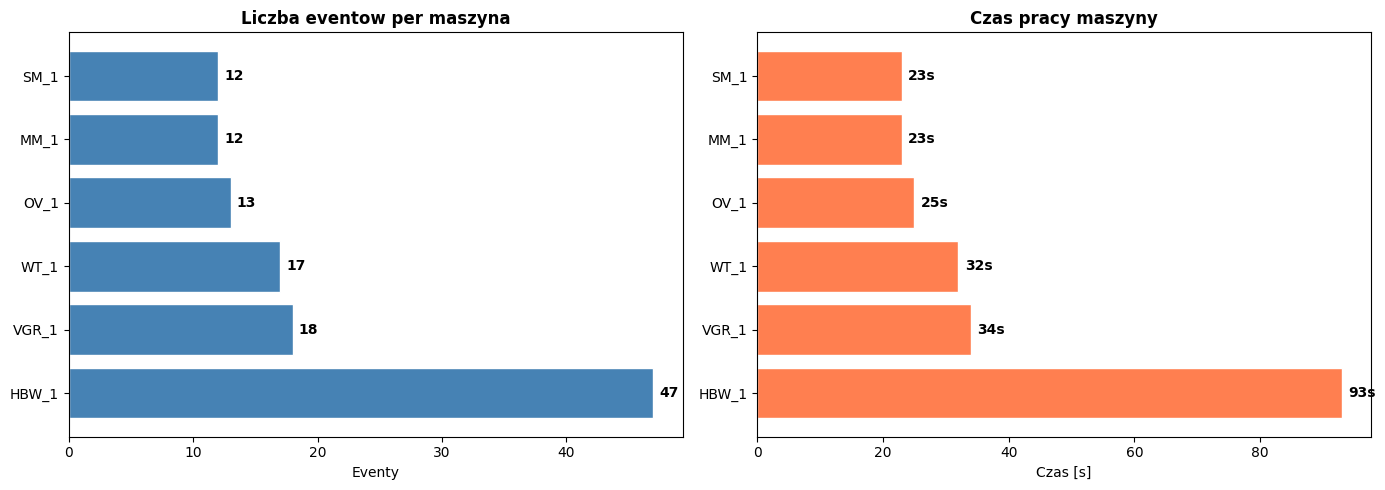

Wykres zapisany: m3_station_load.png


In [17]:
# 7.1 Obciazenie maszyn
station_load = df.groupby('station').agg(
    Eventy=('event_index', 'count'),
    Aktywnosc=('activity', 'first'),
    Start=('timestamp', 'min'),
    Koniec=('timestamp', 'max'),
)
station_load['Czas_s'] = (station_load['Koniec'] - station_load['Start']).dt.total_seconds()
station_load['Eventy_per_s'] = (station_load['Eventy'] / station_load['Czas_s']).round(2)
station_load = station_load.sort_values('Czas_s', ascending=False)

print('=== OBCIAZENIE MASZYN (zasobów technicznych) ===')
print(station_load[['Aktywnosc','Eventy','Czas_s','Eventy_per_s']].to_string())

# Wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stations = station_load.index.tolist()
axes[0].barh(stations, station_load['Eventy'], color='steelblue', edgecolor='white')
for i, v in enumerate(station_load['Eventy']):
    axes[0].text(v + 0.5, i, str(int(v)), va='center', fontweight='bold')
axes[0].set_title('Liczba eventow per maszyna', fontweight='bold')
axes[0].set_xlabel('Eventy')

axes[1].barh(stations, station_load['Czas_s'], color='coral', edgecolor='white')
for i, v in enumerate(station_load['Czas_s']):
    axes[1].text(v + 1, i, f'{int(v)}s', va='center', fontweight='bold')
axes[1].set_title('Czas pracy maszyny', fontweight='bold')
axes[1].set_xlabel('Czas [s]')
plt.tight_layout()
plt.savefig('m3_station_load.png', dpi=120, bbox_inches='tight')
plt.show()
print('Wykres zapisany: m3_station_load.png')


Sekwencja stacji: OV_1 -> SM_1 -> HBW_1 -> MM_1 -> WT_1 -> VGR_1


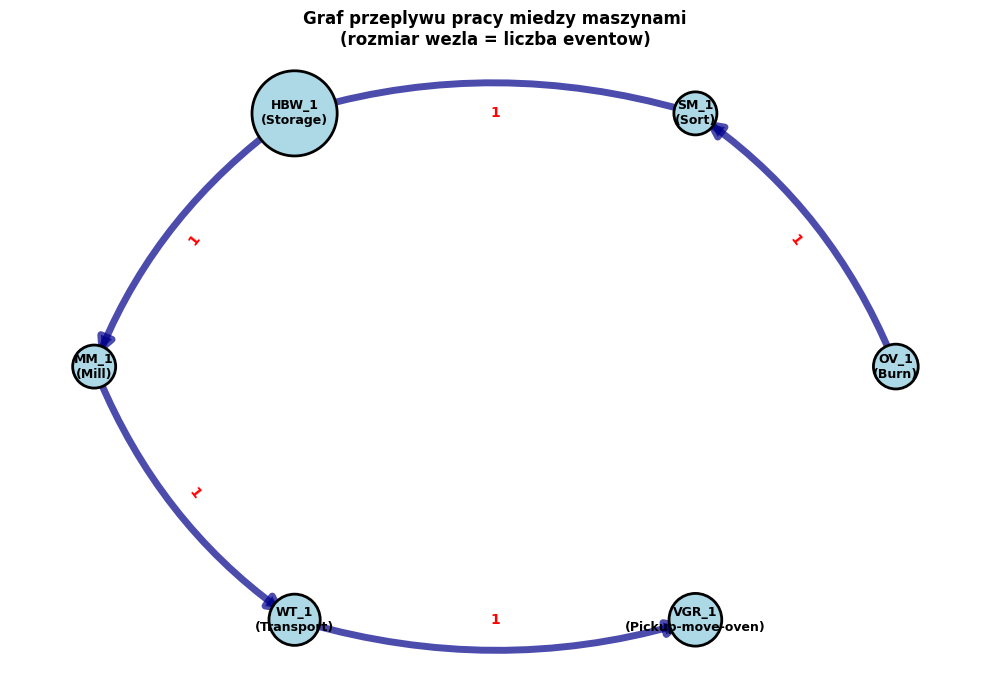

Wykres zapisany: m3_handover_network.png


In [18]:
# 7.2 Graf przeplywu pracy miedzy maszynami (handover-of-work)
# Sekwencja stacji w porzadku globalnym (collapse repeats)
station_seq_global = []
prev = None
for _, row in df_sorted.iterrows():
    s = row['station']
    if s != prev:
        station_seq_global.append(s)
        prev = s

print(f'Sekwencja stacji: {" -> ".join(station_seq_global)}')

# Graf przeplywu
handover = Counter()
for i in range(len(station_seq_global) - 1):
    handover[(station_seq_global[i], station_seq_global[i+1])] += 1

fig, ax = plt.subplots(figsize=(10, 7))
G = nx.DiGraph()
for (a, b), c in handover.items():
    G.add_edge(a, b, weight=c)
for s in df['station'].unique():
    G.add_node(s)

pos = nx.circular_layout(G)
node_sizes = [station_load.loc[n, 'Eventy'] * 80 if n in station_load.index else 500 for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax, node_color='lightblue',
                        node_size=node_sizes, edgecolors='black', linewidths=2)
labels = {n: f'{n}\n({station_load.loc[n, "Aktywnosc"]})' if n in station_load.index else n
          for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=9, font_weight='bold')
weights = [d['weight'] for _, _, d in G.edges(data=True)]
max_w = max(weights) if weights else 1
widths = [1 + 4 * w / max_w for w in weights]
nx.draw_networkx_edges(G, pos, ax=ax, width=widths, alpha=0.7,
                        arrows=True, arrowsize=22, edge_color='darkblue',
                        connectionstyle='arc3,rad=0.15')
edge_labels = {(a, b): str(d['weight']) for a, b, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
                              font_size=10, font_color='red', font_weight='bold')
ax.set_title('Graf przeplywu pracy miedzy maszynami\n(rozmiar wezla = liczba eventow)',
             fontweight='bold', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('m3_handover_network.png', dpi=120, bbox_inches='tight')
plt.show()
print('Wykres zapisany: m3_handover_network.png')


## 8. Identyfikacja wąskich gardeł procesu

Analizujemy:
- czas trwania każdej aktywności
- przerwy między aktywnościami
- liczbę eventów (złożoność) per aktywność


In [19]:
# 8.1 Statystyki czasowe
stats = df.groupby('activity').agg(
    Stacja=('station', 'first'),
    Eventy=('event_index', 'count'),
    Start=('timestamp', 'min'),
    Koniec=('timestamp', 'max'),
)
stats['Czas_s'] = (stats['Koniec'] - stats['Start']).dt.total_seconds().astype(int)
stats['Sygnaly'] = [df[df['activity']==a][SIG_COLS].notna().any().sum() for a in stats.index]
stats = stats.sort_values('Czas_s', ascending=False)
print('=== CZASY TRWANIA AKTYWNOSCI (potencjalne waskie gardla) ===')
print(stats[['Stacja','Eventy','Czas_s','Sygnaly']].to_string())

total = stats['Czas_s'].sum()
print(f'\nSuma czasow: {total} s')
for act in stats.index:
    pct = stats.loc[act, 'Czas_s'] / total * 100
    print(f'  {act:20s}: {stats.loc[act,"Czas_s"]:3d} s ({pct:5.1f}% sumy)')


=== CZASY TRWANIA AKTYWNOSCI (potencjalne waskie gardla) ===
                 Stacja  Eventy  Czas_s  Sygnaly
activity                                        
Storage           HBW_1      47      93       12
Pickup-move-oven  VGR_1      18      34       10
Transport          WT_1      17      32        6
Burn               OV_1      13      25        6
Mill               MM_1      12      23        9
Sort               SM_1      12      23       10

Suma czasow: 230 s
  Storage             :  93 s ( 40.4% sumy)
  Pickup-move-oven    :  34 s ( 14.8% sumy)
  Transport           :  32 s ( 13.9% sumy)
  Burn                :  25 s ( 10.9% sumy)
  Mill                :  23 s ( 10.0% sumy)
  Sort                :  23 s ( 10.0% sumy)


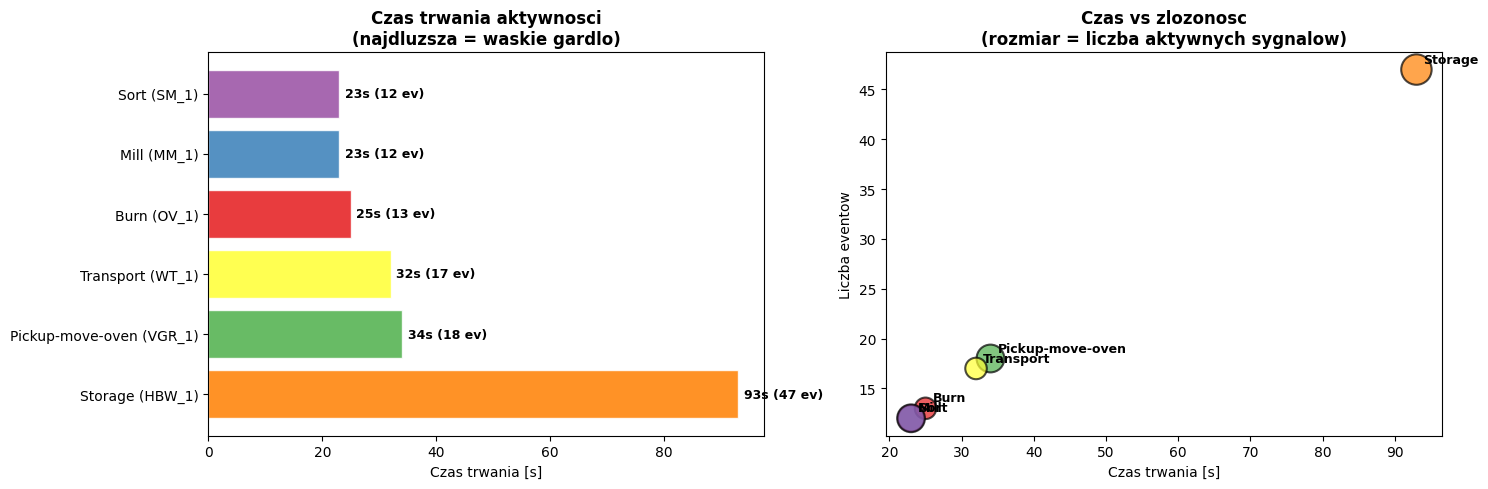

Wykres zapisany: m3_bottlenecks.png

=== GLOWNE WASKIE GARDLO ===
Aktywnosc: Storage
Stacja: HBW_1
Czas: 93 s (40% sumy)
Eventy: 47 (39% wszystkich)


In [20]:
# 8.2 Wizualizacja waskich gardel
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Czas trwania (gantt-style)
color_map_act = {a: plt.cm.Set1.colors[i] for i, a in enumerate(activities)}
y_pos = list(range(len(stats)))
axes[0].barh(y_pos, stats['Czas_s'], color=[color_map_act[a] for a in stats.index],
              edgecolor='white', alpha=0.85)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([f'{a} ({stats.loc[a,"Stacja"]})' for a in stats.index])
axes[0].set_xlabel('Czas trwania [s]')
axes[0].set_title('Czas trwania aktywnosci\n(najdluzsza = waskie gardlo)', fontweight='bold')
for i, (a, row) in enumerate(stats.iterrows()):
    axes[0].text(row['Czas_s'] + 1, i, f'{int(row["Czas_s"])}s ({row["Eventy"]} ev)',
                 va='center', fontweight='bold', fontsize=9)

# Czas vs zlozonosc (eventy)
axes[1].scatter(stats['Czas_s'], stats['Eventy'], s=stats['Sygnaly']*40,
                c=[color_map_act[a] for a in stats.index], alpha=0.7, edgecolors='black', linewidths=1.5)
for a, row in stats.iterrows():
    axes[1].annotate(a, (row['Czas_s'], row['Eventy']),
                     xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Czas trwania [s]')
axes[1].set_ylabel('Liczba eventow')
axes[1].set_title('Czas vs zlozonosc\n(rozmiar = liczba aktywnych sygnalow)', fontweight='bold')
plt.tight_layout()
plt.savefig('m3_bottlenecks.png', dpi=120, bbox_inches='tight')
plt.show()
print('Wykres zapisany: m3_bottlenecks.png')

# Identyfikacja
bottleneck = stats.iloc[0]
print(f'\n=== GLOWNE WASKIE GARDLO ===')
print(f'Aktywnosc: {bottleneck.name}')
print(f'Stacja: {bottleneck["Stacja"]}')
print(f'Czas: {bottleneck["Czas_s"]} s ({bottleneck["Czas_s"]/total*100:.0f}% sumy)')
print(f'Eventy: {bottleneck["Eventy"]} ({bottleneck["Eventy"]/len(df)*100:.0f}% wszystkich)')


## 9. Interpretacja procesu i wnioski

### Co mówi model o systemie?

Analizowany system to laboratoryjna fabryka **Fischertechnik** – cyber-fizyczny system
produkcyjny z 6 stacjami:

| Stacja | Maszyna | Aktywność | Rola w procesie |
|--------|---------|-----------|-----------------|
| HBW_1 | Magazyn wysokiego składowania | Storage | Składowanie surowca / produktu |
| VGR_1 | Robot chwytakowy | Pickup-move-oven | Transport między stacjami |
| OV_1 | Piec | Burn | Obróbka termiczna |
| MM_1 | Frezarka | Mill | Obróbka skrawaniem |
| SM_1 | Sortownica | Sort | Klasyfikacja produktów |
| WT_1 | Wózek transportowy | Transport | Transport wewnętrzny |

### Najczęstsze ścieżki

Dane zawierają **6 sygnatur** (po jednej na aktywność) – nie pełen przepływ produkcji.
Obserwowana sekwencja w czasie: Burn → Sort → Storage → Mill → Transport → Pickup-move-oven.

Klasyczny przepływ produkcyjny (z dokumentacji Fischertechnik):
**Storage → Pickup → Burn → Mill/Sort → Transport**

### Gdzie pojawiają się opóźnienia?

- **Storage** – najdłuższa aktywność (93 s, 39% sumy czasów) – to **główne wąskie gardło**
- **Pickup-move-oven** – 34 s, najwyższa dynamika sygnałów (67% przejść)
- **Mill, Sort, Burn** – podobne czasy (~23–25 s) – mogą działać równolegle

### Potencjalne usprawnienia

1. **Równoległość Mill/Sort** – obie aktywności po Burn mogą działać równolegle (oddzielne maszyny)
2. **Optymalizacja Storage** – największe wąskie gardło; zmniejszenie liczby ruchów 3D
3. **Buforowanie między etapami** – pozwoliłoby na częściową równoległość produkcji
4. **Reguly decyzyjne** – dodanie bramki XOR po Burn (Mill albo Sort wg typu detalu)
5. **Monitoring sprzężony z CEP** – detekcja anomalii w czasie rzeczywistym

### Wnioski biznesowe

- **System jest deterministyczny** – każda aktywność wykonuje tę samą sekwencję sygnałów
- **Klasteryzacja sygnałów odtwarza aktywności z ARI=0.914** – możliwa automatyczna klasyfikacja stanów
- **Burn i Transport mają podobne profile** – można optymalizować wspólnie (oba używają zaworu pneumatycznego)
- **Storage = największe pole do optymalizacji** – redukcja czasu o 50% dałaby ~20% przyspieszenia całego procesu
- **Aplikacje CEP (Siddhi) potwierdzone** – wszystkie 15 wzorców wykrytych w danych (M2)


In [21]:
# Finalne podsumowanie liczbowe
print('=' * 70)
print('PODSUMOWANIE MILESTONE 3 – KLUCZOWE LICZBY')
print('=' * 70)
print(f'Eventow: {len(df)}, Aktywnosci: {len(activities)}, Stacji: {df["station"].nunique()}')
print(f'\nDFG na aktywnosciach: {len(dfg_act)} krawedzi')
print(f'DFG na klastrach:     {len(dfg_clust)} krawedzi')
print(f'\nModele procesu:')
for r in comparison:
    if r['Fitness'] != 'N/A':
        print(f'  {r["Model"]:20s}: fitness={r["Fitness"]}, prec={r["Precision"]}, '
              f'gen={r["Generalization"]}, simp={r["Simplicity"]}')
print(f'\nDrzewo decyzyjne accuracy: {dt.score(X_dt, y_dt):.3f}')
print(f'\nGlowne waskie gardlo: {bottleneck.name} ({bottleneck["Czas_s"]} s, '
      f'{bottleneck["Czas_s"]/total*100:.0f}% sumy)')


PODSUMOWANIE MILESTONE 3 – KLUCZOWE LICZBY
Eventow: 119, Aktywnosci: 6, Stacji: 6

DFG na aktywnosciach: 5 krawedzi
DFG na klastrach:     5 krawedzi

Modele procesu:
  Alpha Miner         : fitness=1.0, prec=1.0, gen=0.0, simp=1.0
  Inductive Miner     : fitness=1.0, prec=1.0, gen=0.0, simp=1.0

Drzewo decyzyjne accuracy: 1.000

Glowne waskie gardlo: Storage (93 s, 40% sumy)
